In [ ]:
# E - Model Interpretation

#This notebook  explains the behaviour of the trained race strategy model.

## Goals
#Load the trained model
#Inspect important features
#Compare predictions with actual values
#Summarize key findings for the research paper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
DATA_PATH = Path("../data/processed/master_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [3]:
MODEL_PATH = Path("../models/best_model.pkl")
model = joblib.load(MODEL_PATH)

print("Model loaded successfully")
print(model)

Model loaded successfully
RandomForestRegressor(n_jobs=-1, random_state=42)


In [4]:
feature_cols = [
    "LapNumber",
    "TyreLife",
    "Stint",
    "Position",
    "TrackStatus",
    "FuelLoadApprox",
    "StintProgress",
    "CompoundEncoded",
    "FreshTyre",
    "TyreAgeSquared"
]

target_col = "LapTimeSeconds"

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11880, 10)
y shape: (11880,)


In [5]:
y_pred = model.predict(X)

print("Prediction complete")
print("Sample predictions:")
print(y_pred[:10])

Prediction complete
Sample predictions:
[91.48754714 88.39408007 88.013654   94.59778183 92.63050838 93.15048329
 89.13933083 91.87351214 97.49292167 90.62767733]


In [6]:
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Model Evaluation")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
MAE  : 2.7729
RMSE : 4.0835
R²   : 0.8012


,Feature,Importance
6,StintProgress,0.206497
3,Position,0.196518
5,FuelLoadApprox,0.134032
0,LapNumber,0.130669
1,TyreLife,0.094141
9,TyreAgeSquared,0.093446
7,CompoundEncoded,0.068206
2,Stint,0.044766
8,FreshTyre,0.031726
4,TrackStatus,0.000000


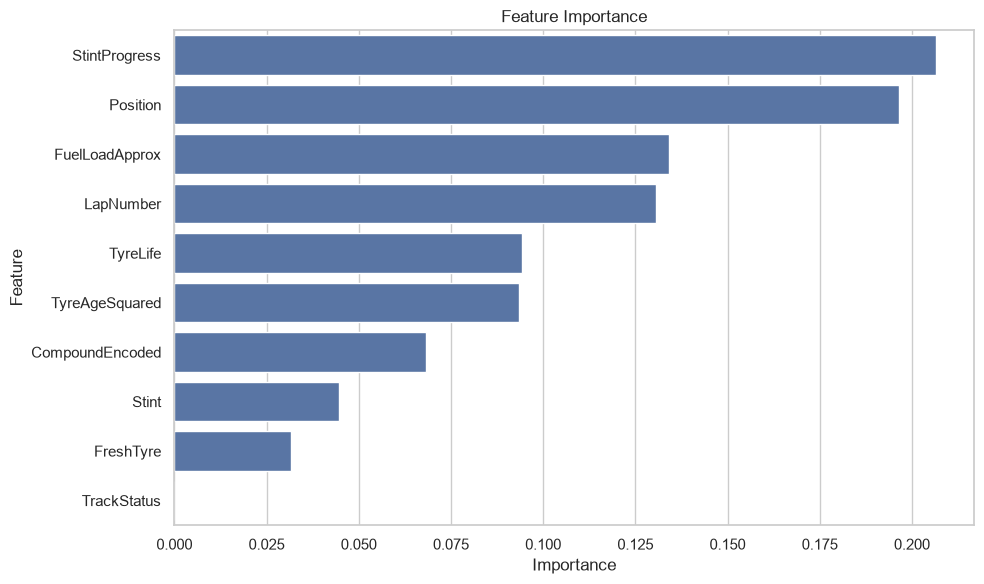

In [7]:
if hasattr(model, "feature_importances_"):
    importances = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importances)

    plt.figure(figsize=(10,6))
    sns.barplot(data=importances, x="Importance", y="Feature")
    plt.title("Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("This model does not expose feature_importances_.")

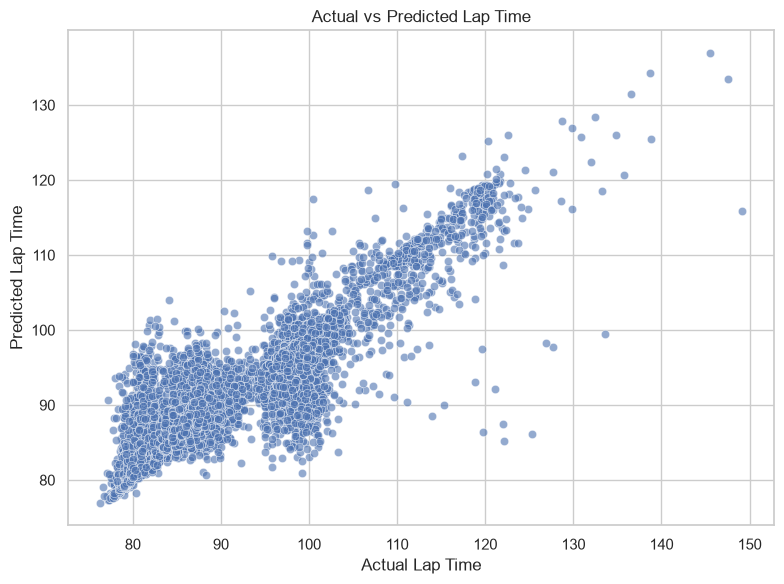

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Actual vs Predicted Lap Time")
plt.tight_layout()
plt.show()

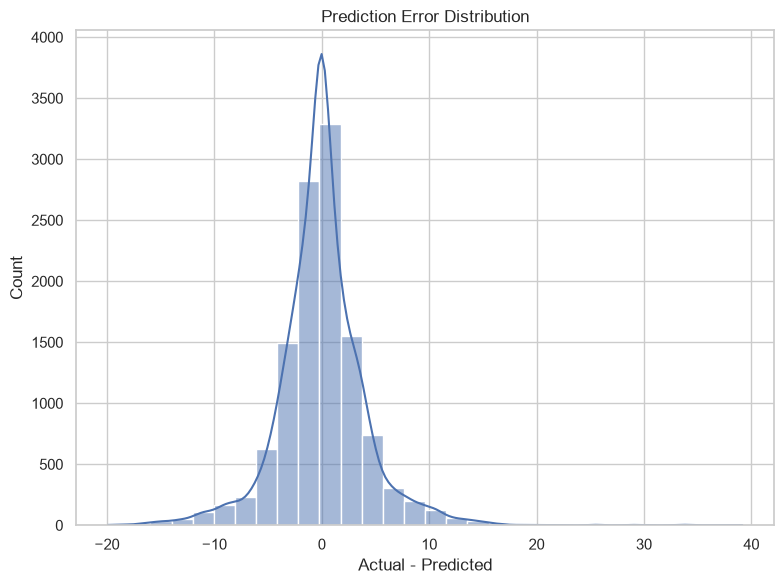

In [9]:
errors = y - y_pred

plt.figure(figsize=(8,6))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Actual - Predicted")
plt.tight_layout()
plt.show()

In [10]:
comparison_df = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred,
    "Error": y - y_pred
})

comparison_df.head(10)

,Actual,Predicted,Error
0,83.186,91.487547,-8.301547
1,79.871,88.394080,-8.523080
2,79.364,88.013654,-8.649654
3,80.766,94.597782,-13.831782
4,80.827,92.630508,-11.803508
5,80.876,93.150483,-12.274483
6,80.973,89.139331,-8.166331
7,80.989,91.873512,-10.884512
8,81.042,97.492922,-16.450922
9,81.003,90.627677,-9.624677


In [11]:
output_path = Path("../outputs/tables")
output_path.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(output_path / "model_predictions_vs_actual.csv", index=False)

print("Saved predictions comparison table to outputs/tables/")

Saved predictions comparison table to outputs/tables/


In [12]:
print("=== Model Interpretation Summary ===\n")

print("1. The trained model predicts lap time using tyre, stint, fuel and race-state related features.")
print("2. Feature importance identifies which race variables most influence lap time prediction.")
print("3. The actual vs predicted plot helps judge how closely predictions follow real lap times.")
print("4. The error distribution shows whether prediction mistakes are centered around zero or biased.")
print("5. This notebook supports the explainability section of the research paper.")

=== Model Interpretation Summary ===

1. The trained model predicts lap time using tyre, stint, fuel and race-state related features.
2. Feature importance identifies which race variables most influence lap time prediction.
3. The actual vs predicted plot helps judge how closely predictions follow real lap times.
4. The error distribution shows whether prediction mistakes are centered around zero or biased.
5. This notebook supports the explainability section of the research paper.
